In [23]:


from src.agents.nodes.generate_sql_node import generate_sql_node
from utils.sql_tools import WmsSqlTool
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool, QuerySQLCheckerTool, InfoSQLDatabaseTool,ListSQLDatabaseTool
from langchain_google_genai import ChatGoogleGenerativeAI
from src.config import settings

_llm = None

def _getllm() -> ChatGoogleGenerativeAI:
    global _llm

    if _llm is None:
        _llm = ChatGoogleGenerativeAI(
            model=settings.GOOGLE_AI_MODEL,
            api_key=settings.GOOGLE_API_KEY,


        )
    return _llm
tools = WmsSqlTool(query_check_llm=_getllm())

query_tool = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLDatabaseTool))
query_check = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLCheckerTool))
list_tables = next(t for t in tools.get_sql_tools() if isinstance(t, ListSQLDatabaseTool))
list_info = next(t for t in tools.get_sql_tools() if isinstance(t, InfoSQLDatabaseTool))

res= list_info.invoke({"table_names": list_tables.invoke("")})


In [ ]:
res

In [ ]:
tool = tools.get_sql_tools()

next(t for t in tool if isinstance(t, QuerySQLDatabaseTool))

In [ ]:
from pprint import pprint
check_sql = "select * from inventory wher limit 10"
checked_sql = query_check.invoke({"query": check_sql})
pprint(checked_sql)


In [25]:
from data.state import WMState
from agents.nodes.router import router_node

state = WMState(
    ticket_number= "INC12345",
    description= "how to slot sku003 and how much",
    user_id= "rahul"
)

router = router_node(state)

router


{'intent': 'diagnose', 'domain': 'inventory'}

In [2]:
from agents.graph.sql_subgraph import sql_graph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from dotenv import load_dotenv
load_dotenv()
state = SQLGraphState(

    description= "how many picks left?",
    domain="outbound"
)

router = sql_graph.invoke(state)

from rich.console import Console
from rich.markdown import Markdown
console = Console()

console.print(Markdown(router['final_response']))


                  
 total_picks_left 
 ──────────────── 
            25206 
                  

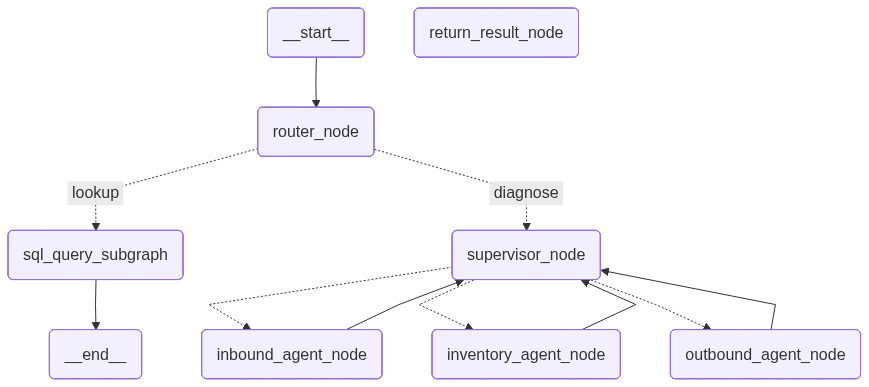

In [3]:
from langgraph.graph import StateGraph, START, END
from src.data.state import WMState
from IPython.display import display, Image
from src.agents.nodes.router import router_node
from agents.graph.sql_subgraph import sql_graph
from src.agents.nodes.sql_result_node import return_result_node
from src.agents.edges.router_intent_edge import router_intent_edge
from langgraph.cache.memory import InMemoryCache
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from agents.nodes.outbound_agent_node import outbound_agent_node
from agents.nodes.inventory_agent_node import inventory_agent_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = (SupervisorNode())

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph", sql_graph)
builder.add_node("return_result_node", return_result_node)
builder.add_node("supervisor_node", supervisor_node)
builder.add_node("inbound_agent_node", inbound_agent_node)
builder.add_node("outbound_agent_node", outbound_agent_node)
builder.add_node("inventory_agent_node", inventory_agent_node)


builder.add_edge(START, "router_node")
builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup":"sql_query_subgraph",
        "diagnose": "supervisor_node"
    }
)
builder.add_conditional_edges(
    "supervisor_node",
    lambda state: ["inbound_agent_node", "outbound_agent_node", "inventory_agent_node"],
    {
        "inbound_agent_node": "inbound_agent_node",
        "outbound_agent_node": "outbound_agent_node",
        "inventory_agent_node": "inventory_agent_node",
    }
)

# Agents → back to supervisor
builder.add_edge("inbound_agent_node", "supervisor_node")
builder.add_edge("outbound_agent_node", "supervisor_node")
builder.add_edge("inventory_agent_node", "supervisor_node")

# Supervisor can also go to result
builder.add_edge("return_result_node", END)

graph = builder.compile(cache=InMemoryCache())

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
result = await graph.ainvoke(
    {
        "ticket_number": "INC12345",
        "description": "what all issues in inbound ?",
        "user_id": "rahul",
        "domain": "inventory",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_response") or str(result)
print("FINAL_TEXT:", repr(final_text))

console.print(Markdown(final_text))

In [ ]:


from langchain_core.messages import HumanMessage

from data.state import WMState
from models.model_loader import get_google_llm

get_google_llm().invoke([HumanMessage(content="Hello")]).content[0]["text"].strip()

In [4]:


from agents.nodes.supervisor_node import SupervisorNode
from data.state import WMState

message = (
   "picking is low and uph is low but invenotry is high why and also inbound has no work"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)


node = SupervisorNode()
response = await node(state)
print(response)


Command(update={'active_task_id': 'f51609c8-5b75-484e-b247-bc76b21c66a0', 'loop_count': 1, 'messages': [AIMessage(content='Supervisor delegated task inventory_agent to f51609c8-5b75-484e-b247-bc76b21c66a0', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='Supervisor delegated task outbound_agent to f51609c8-5b75-484e-b247-bc76b21c66a0', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='Supervisor delegated task inbound_agent to f51609c8-5b75-484e-b247-bc76b21c66a0', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}, goto=[Send(node='inventory_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='inventory_agent', task='Analyze inventory levels and location accuracy to identify why high inventory levels are not translating into higher picking efficiency.')), Send(node='outbound_agent', arg=WorkerInput(task_id='f51609c8-5

In [11]:
for data in response.goto:
    print(data)
    print("="*90)


Send(node='inventory_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='inventory_agent', task='Analyze inventory levels and location accuracy to identify why high inventory levels are not translating into higher picking efficiency.'))
Send(node='outbound_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='outbound_agent', task='Evaluate picking processes, warehouse layout, and staff performance metrics to determine the cause of low UPH.'))
Send(node='inbound_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='inbound_agent', task='Review inbound scheduling and receiving data to confirm the lack of current inbound work and potential impact on warehouse flow.'))


In [1]:
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from data.state import WMState, WorkerInput

AGENTS = {
    "inbound_agent": inbound_agent_node,
    # "outbound_agent": outbound_agent_node,
    # "inventory_agent": inventory_agent_node,
}

message = (
    "whats the over wms load"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)

supervisor = SupervisorNode()

# Run supervisor
cmd = await supervisor(state)
print("Supervisor returned:")
print(cmd)


Supervisor returned:
Command(update={'active_task_id': '3e6a78cf-632f-47ff-80ce-4203804ed03d', 'loop_count': 1, 'messages': [AIMessage(content='Supervisor delegated task inbound_agent to 3e6a78cf-632f-47ff-80ce-4203804ed03d', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='Supervisor delegated task outbound_agent to 3e6a78cf-632f-47ff-80ce-4203804ed03d', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='Supervisor delegated task inventory_agent to 3e6a78cf-632f-47ff-80ce-4203804ed03d', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}, goto=[Send(node='inbound_agent', arg=WorkerInput(task_id='3e6a78cf-632f-47ff-80ce-4203804ed03d', agent_name='inbound_agent', task='Investigate current dock congestion, receipt processing rates, and putaway backlog to assess inbound load.')), Send(node='outbound_agent', arg=WorkerInput(task_id='3e6a78cf-632f-47ff-80ce

In [22]:
from agents.graph.sql_subgraph import sql_graph
from data.state import SQLGraphState
state2 = SQLGraphState(
    domain="outbound",
    description="how much left in picking outbound and what all skus"
)

res = sql_graph.invoke(state2)

res

'SELECT \n    sku, \n    SUM(quantity - COALESCE(pck_qty, 0)) AS remaining_quantity\nFROM wms1.pckwrk\nWHERE COALESCE(pck_qty, 0) < quantity\nGROUP BY sku;'

In [23]:
state2 = SQLGraphState(
    domain="outbound",
    description="how much sku do we need for picking"
)

res = sql_graph.invoke(state2)

res

{'domain': 'outbound',
 'description': 'how much sku do we need for picking',
 'skill_context': "\n# Outbound Picking\n\n## Tables\n\n### wms1.pckwrk\n- id\n- wrkref\n- location\n- sku\n- dtl_num\n- quantity\n- pck_qty\n- app_qty\n- carton_number\n- pck_dt\n- status\n- ins_dt\n- order_number\n\n## Use Cases\n- Pending pick work\n- Requested vs picked quantity\n- Picked units over time\n- Warehouse-level hourly pick volume\n\n## Business Rules\n- quantity = requested quantity\n- pck_qty = picked quantity\n- pck_dt = pick timestamp\n- Warehouse average UPH for the last 24 hours can be approximated as total picked units in last 24 hours divided by 24\n- This table does not support true user-level UPH because there is no picker/operator field\n\n## Example Queries\n\n-- Warehouse average UPH over last 24 hours\nSELECT\n    SUM(COALESCE(pck_qty, 0)) AS total_units_picked_24h,\n    SUM(COALESCE(pck_qty, 0)) / 24.0 AS avg_uph_24h\nFROM wms1.pckwrk\nWHERE pck_dt >= NOW() - INTERVAL '24 hours'\

In [1]:
from models.model_loader import get_openai_fast_llm
from domain.states.supervisor.supervisor_subagent_task_state import SupervisorToSubAgentDeligationItem

llm = get_openai_fast_llm().with_structured_output(SupervisorToSubAgentDeligationItem)

response = llm.invoke([
    {"role": "system", "content": "You are a WMS diagnose agent elaborate issues in depth"},
    {"role": "user", "content": "whats my inbound issues"}
])

response

SupervisorToSubAgentDeligationItem(subagent_deligations=[SubAgentTaskInvokeItem(subagent_name='inbound_agent_node', subagent_task='diagnose_inbound_issues', domain_name='inbound')])

In [2]:
for data in response.subagent_deligations:
    print(data.subagent_task)
    print("="*19)

diagnose_inbound_issues


In [5]:
from agents.nodes.supervisor_node import SupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

message = (
    "whats inbound staus"
)
state = WMState(
    ticket_number="INC12345",
    description=message,
)


node = SupervisorNode()
response = await node(state)
print(response)


# subagent_name= subagent_name,
#             worker_task=subagent_research_task,
#             task_id=str(task_id),
#             domain_name=domain,

Command(update={'loop_count': 3, 'messages': [AIMessage(content='Supervisor delegated task to inbound_agent_node', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}, goto=[Send(node='inbound_agent_node', arg=SupervisorWorkerPayloadState(domain_name='inbound', worker_task='Investigate the current status of inbound operations, including dock availability, trailer backlog, ASN/PO processing times, and putaway efficiency to provide a comprehensive overview.', subagent_name='inbound_agent_node', loop_counter=2))])


In [2]:
response.goto

[Send(node='inbound_agent_node', arg=SupervisorWorkerPayloadState(domain_name='inbound', worker_task='Investigate the current status of inbound operations, including dock activity, trailer volume, receiving backlog, and ASN/PO processing to provide a comprehensive overview.', subagent_name='inbound_agent_node', loop_counter=0))]

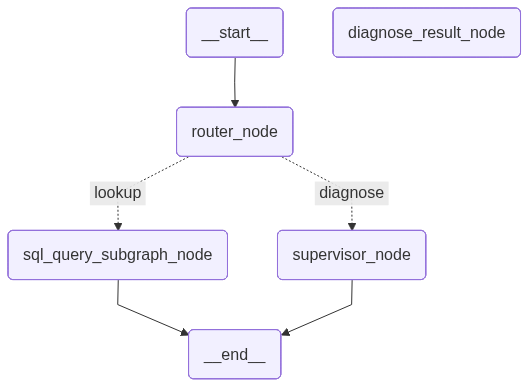

In [1]:
from langgraph.graph import StateGraph, START, END
from domain.states.supervisor.diagnose_graph_state import WMState
from IPython.display import display, Image
from src.agents.nodes.router import router_node
from agents.graph.sql_subgraph import sql_graph
from agents.edges.router_intent_edge import router_intent_edge
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.diagnose_result_node import diagnose_result_node
from agents.nodes.sql_lookup_subgraph_node import sql_query_subgraph_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = WarehouseSupervisorNode()

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph_node", sql_query_subgraph_node)

builder.add_node("supervisor_node", supervisor_node)
builder.add_node("diagnose_result_node", diagnose_result_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup": "sql_query_subgraph_node",
        "diagnose": "supervisor_node",
    },
)

# lookup path ends here
builder.add_edge("sql_query_subgraph_node", END)

# diagnose_result_node is your explicit finish node
builder.add_edge("diagnose_result_node", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [9]:

result = await graph.ainvoke(
    {
        "ticket_number":"INC12345",
        "description":"what status of inbound ?",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_responses") or str(result)

console.print(Markdown(final_text['final_responses']))

<class 'dict'>
{'ticket_number': 'INC12345', 'description': 'what status of inbound ?', 'intent': 'lookup', 'domain': 'inbound', 'messages': [], 'final_responses': {'domain': 'inbound', 'description': 'what status of inbound ?', 'skill_context': '\n# Inbound Receiving\n\n## Tables\n\n### wms1.rcv_inventory\n- rcv_id (PRIMARY KEY)\n- rcv_inv\n- warehouse_id\n- sku\n- supplier_number\n- expected_qty\n- received_qty\n- received_date\n- receiving_loc\n- status\n- created_at\nWARNING: There is NO column called "receiving_date". The correct name is "received_date".\n## Use Cases\n- What receipts exist for a SKU?\n- How much was expected vs received?\n- Which receiving location was used?\n- Which receipts are pending, partial, received, or cancelled?\n\n## Business Rules\n- expected_qty is the planned receipt quantity.\n- received_qty is the actual received quantity recorded.\n- status is one of: PENDING, PARTIAL, RECEIVED, CANCELLED.\n- Quantity variance can be checked as expected_qty - rece

           
 status    
 ───────── 
 CANCELLED 
 PARTIAL   
 PENDING   
 RECEIVED  
           

In [10]:
final_text['final_responses']

'| status    |\n|:----------|\n| CANCELLED |\n| PARTIAL   |\n| PENDING   |\n| RECEIVED  |'

In [1]:
from agents.nodes.router import router_node
from domain.states.supervisor.diagnose_graph_state import WMState

state = WMState(
    ticket_number="INC12345",
    description="what is the sttus of sku 003",
    session_id="rahul"
)

res = router_node(state)

print(res)

{'routing_decision': {'intent': 'lookup', 'domain': 'inventory'}}
